In [2]:
from sklearn.datasets import make_circles

In [11]:
n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

In [12]:
X[:5],y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [13]:
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
                        "X2" : X[:, 1],
                        "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [14]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

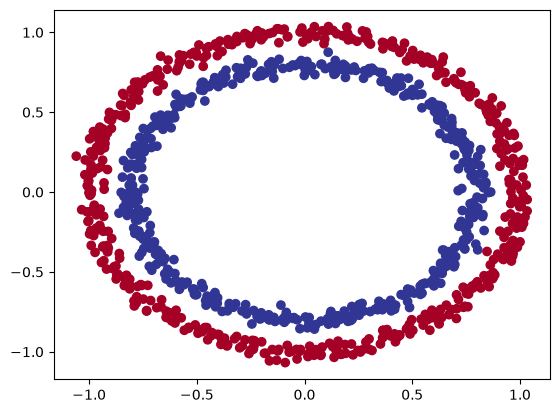

In [15]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0], 
            y=X[:, 1], 
            c=y, 
            cmap=plt.cm.RdYlBu);

In [23]:
import torch
torch.from_numpy(X).type(torch.float)
torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = torch.from_numpy(X_train).type(torch.float), torch.from_numpy(X_test).type(torch.float), torch.from_numpy(y_train).type(torch.float), torch.from_numpy(y_test).type(torch.float)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [5]:
from torch import nn

device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [26]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x):
        return self.layer_2(self.layer_1(x))

model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [33]:
untrained_preds = model_0(X_test.to(device))

In [34]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [11]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [36]:
y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.2750],
        [-0.3916],
        [-0.0288],
        [-0.3445],
        [-0.1234]], device='mps:0', grad_fn=<SliceBackward0>)

In [37]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4317],
        [0.4033],
        [0.4928],
        [0.4147],
        [0.4692]], device='mps:0', grad_fn=<SigmoidBackward0>)

In [38]:
y_preds = torch.round(y_pred_probs)

y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True], device='mps:0')


tensor([0., 0., 0., 0., 0.], device='mps:0', grad_fn=<SqueezeBackward0>)

In [39]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [40]:
torch.manual_seed(42)

epochs = 100

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_0.train()

    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)

    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()

    with torch.inference_mode():
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)

        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")



Epoch: 0 | Loss: 0.70267, Accuracy: 41.12% | Test loss: 0.69610, Test acc: 45.50%
Epoch: 10 | Loss: 0.69877, Accuracy: 45.88% | Test loss: 0.69292, Test acc: 52.50%
Epoch: 20 | Loss: 0.69698, Accuracy: 47.38% | Test loss: 0.69166, Test acc: 52.00%
Epoch: 30 | Loss: 0.69608, Accuracy: 47.88% | Test loss: 0.69118, Test acc: 54.50%
Epoch: 40 | Loss: 0.69555, Accuracy: 48.12% | Test loss: 0.69102, Test acc: 52.50%
Epoch: 50 | Loss: 0.69521, Accuracy: 48.50% | Test loss: 0.69100, Test acc: 53.50%
Epoch: 60 | Loss: 0.69495, Accuracy: 49.25% | Test loss: 0.69104, Test acc: 53.00%
Epoch: 70 | Loss: 0.69474, Accuracy: 49.00% | Test loss: 0.69111, Test acc: 54.00%
Epoch: 80 | Loss: 0.69457, Accuracy: 49.12% | Test loss: 0.69119, Test acc: 54.00%
Epoch: 90 | Loss: 0.69442, Accuracy: 49.12% | Test loss: 0.69127, Test acc: 54.00%


In [42]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

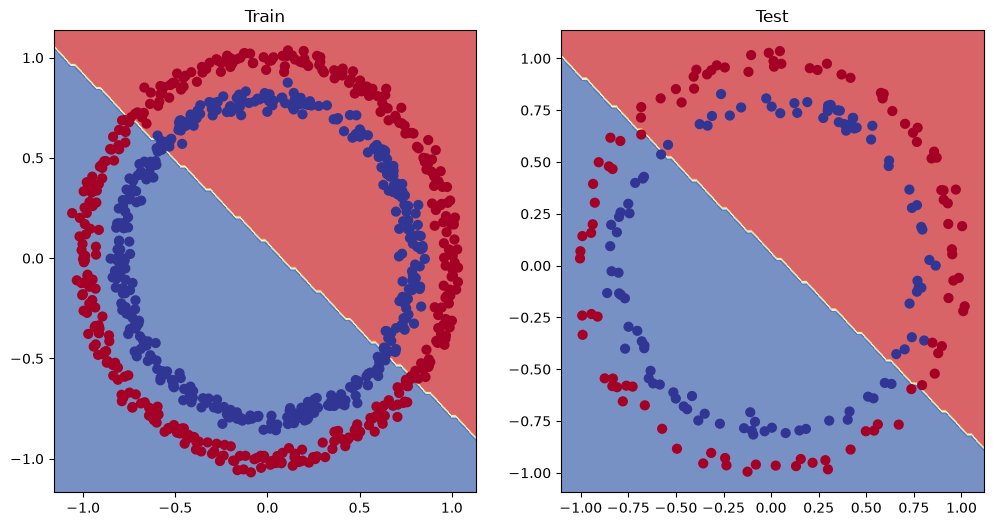

In [43]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [44]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [45]:
train_split = int(0.8 * len(X_regression)) # 80% of data used for training set
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]


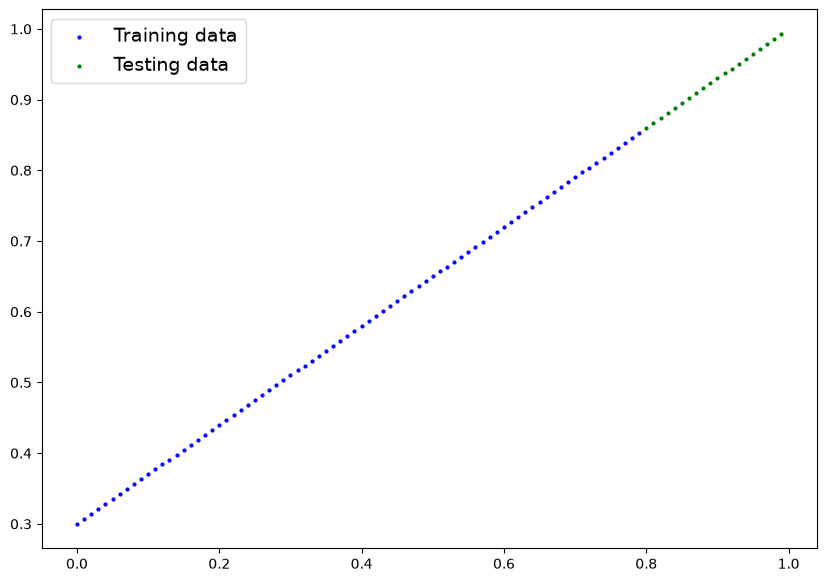

In [47]:
plot_predictions(train_data=X_train_regression, train_labels=y_train_regression, test_data=X_test_regression, test_labels=y_test_regression)

In [48]:
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [49]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)

In [51]:
torch.manual_seed(42)

epochs = 1000

X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    y_pred = model_2(X_train_regression)

    loss = loss_fn(y_pred, y_train_regression)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_2.eval()
    with torch.inference_mode():
        test_pred = model_2(X_test_regression)
        test_loss = loss_fn(test_pred, y_test_regression)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch}, train loss: {loss:.5f}, test loss: {test_loss:.5f}")
        

Epoch: 0, train loss: 0.75986, test loss: 0.54143
Epoch: 100, train loss: 0.09309, test loss: 0.02901
Epoch: 200, train loss: 0.07376, test loss: 0.02850
Epoch: 300, train loss: 0.06745, test loss: 0.00615
Epoch: 400, train loss: 0.06107, test loss: 0.02004
Epoch: 500, train loss: 0.05698, test loss: 0.01061
Epoch: 600, train loss: 0.04857, test loss: 0.01326
Epoch: 700, train loss: 0.06109, test loss: 0.02127
Epoch: 800, train loss: 0.05599, test loss: 0.01426
Epoch: 900, train loss: 0.05571, test loss: 0.00603


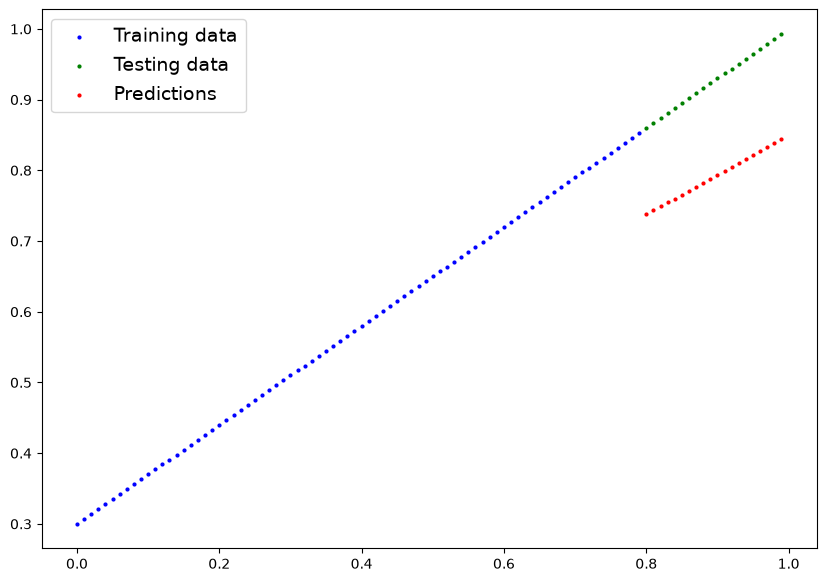

In [52]:
model_2.eval()

with torch.inference_mode():
    y_preds = model_2(X_test_regression)

plot_predictions(train_data=X_train_regression.cpu(), test_data=X_test_regression.cpu(), train_labels=y_train_regression.cpu(), test_labels=y_test_regression.cpu(), predictions=y_preds.cpu())

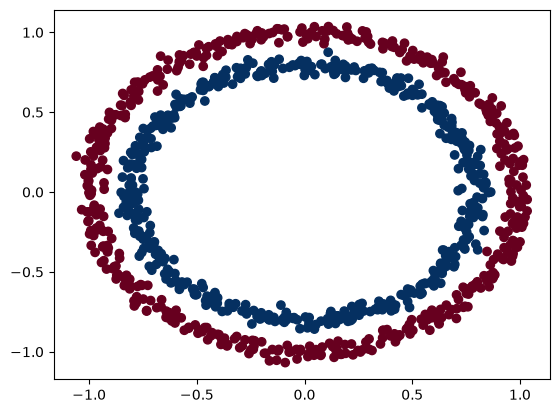

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu)

In [3]:
import torch
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [13]:
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
print(model_3)

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [14]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

In [18]:
torch.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_3.eval()

    with torch.inference_mode():
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} Loss: {loss:.5f} Accuracy: {acc:.5f}")

Epoch: 0 Loss: 0.69998 Accuracy: 50.00000
Epoch: 100 Loss: 0.69008 Accuracy: 62.00000
Epoch: 200 Loss: 0.68643 Accuracy: 62.25000
Epoch: 300 Loss: 0.68288 Accuracy: 63.12500
Epoch: 400 Loss: 0.67763 Accuracy: 65.25000
Epoch: 500 Loss: 0.66955 Accuracy: 68.25000
Epoch: 600 Loss: 0.65650 Accuracy: 69.75000
Epoch: 700 Loss: 0.63396 Accuracy: 76.37500
Epoch: 800 Loss: 0.59149 Accuracy: 87.25000
Epoch: 900 Loss: 0.51434 Accuracy: 96.12500


In [20]:
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

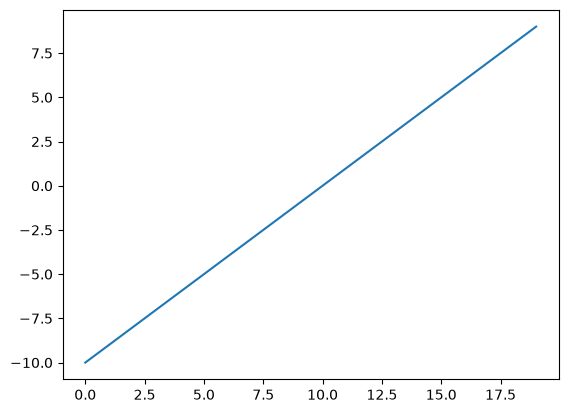

In [21]:
plt.plot(A)

In [22]:
def relu(x):
    return torch.maximum(torch.tensor(0), x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

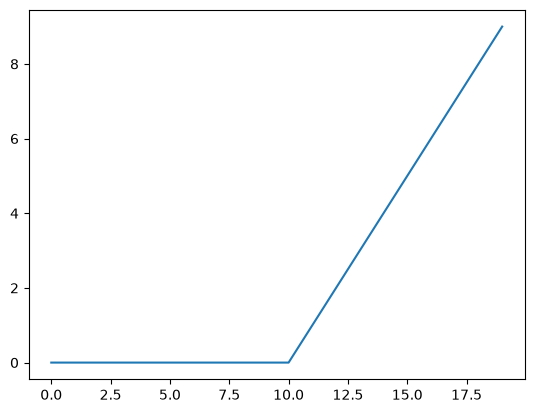

In [23]:
plt.plot(relu(A))

In [24]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

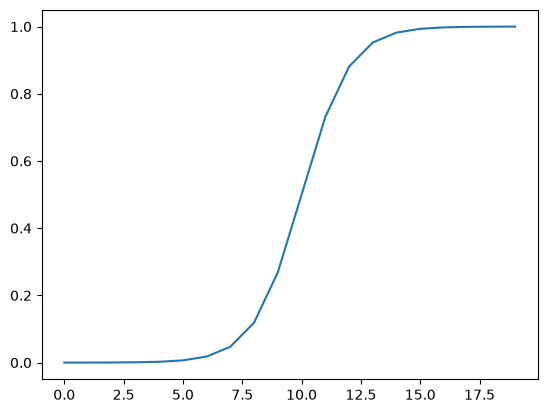

In [25]:
plt.plot(sigmoid(A))

tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


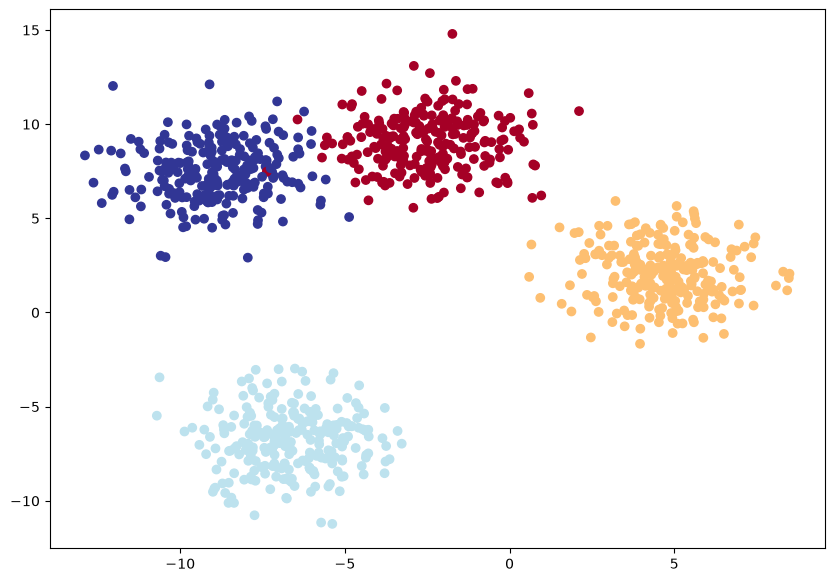

In [1]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(n_samples=1000, n_features=NUM_FEATURES, centers=NUM_CLASSES, cluster_std=1.5, random_state=RANDOM_SEED)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

print(X_blob[:5], y_blob[:5])

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED)

plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

In [3]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [5]:
from torch import nn

class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(input_features, hidden_units),
            nn.Linear(hidden_units, hidden_units),
            nn.Linear(hidden_units, output_features)
        )


    def forward(self, x):
        return self.linear_layer_stack(x)

model_4 = BlobModel(input_features=NUM_FEATURES, output_features=NUM_CLASSES, hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [6]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(), lr=0.1)

In [8]:
model_4(X_blob_train.to(device))[:5]

tensor([[-1.3531,  0.1383,  4.1944,  1.4172],
        [-0.3638,  0.1167,  3.7044,  0.5441],
        [ 3.4590, -0.6419, -8.1452, -1.9846],
        [ 2.2676, -0.4242, -4.7288, -1.1730],
        [ 0.1072,  0.0229,  2.2397,  0.2330]], device='mps:0',
       grad_fn=<SliceBackward0>)

In [9]:
y_logits = model_4(X_blob_train.to(device))

y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-1.3531,  0.1383,  4.1944,  1.4172],
        [-0.3638,  0.1167,  3.7044,  0.5441],
        [ 3.4590, -0.6419, -8.1452, -1.9846],
        [ 2.2676, -0.4242, -4.7288, -1.1730],
        [ 0.1072,  0.0229,  2.2397,  0.2330]], device='mps:0',
       grad_fn=<SliceBackward0>)
tensor([[3.5973e-03, 1.5984e-02, 9.2299e-01, 5.7424e-02],
        [1.5736e-02, 2.5444e-02, 9.1981e-01, 3.9009e-02],
        [9.7954e-01, 1.6218e-02, 8.9401e-06, 4.2354e-03],
        [9.0850e-01, 6.1558e-02, 8.3146e-04, 2.9115e-02],
        [8.7038e-02, 8.0007e-02, 7.3425e-01, 9.8707e-02]], device='mps:0',
       grad_fn=<SliceBackward0>)


In [10]:
torch.sum(y_pred_probs[0])

tensor(1., device='mps:0', grad_fn=<SumBackward0>)

In [16]:
torch.manual_seed(42)

epochs = 100

X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    model_4.train()

    y_logits = model_4(X_blob_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train, y_pred=y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_4.eval()

    with torch.inference_mode():
        test_logits = model_4(X_blob_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)

        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true=y_blob_test, y_pred=test_pred)

    if epoch % 10 == 0:
         print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")
        


Epoch: 0 | Loss: 0.03549, Acc: 98.88% | Test Loss: 0.02662, Test Acc: 99.50%
Epoch: 10 | Loss: 0.03454, Acc: 98.88% | Test Loss: 0.02554, Test Acc: 99.50%
Epoch: 20 | Loss: 0.03376, Acc: 98.88% | Test Loss: 0.02463, Test Acc: 99.50%
Epoch: 30 | Loss: 0.03311, Acc: 98.88% | Test Loss: 0.02387, Test Acc: 99.50%
Epoch: 40 | Loss: 0.03256, Acc: 98.88% | Test Loss: 0.02321, Test Acc: 99.50%
Epoch: 50 | Loss: 0.03209, Acc: 98.88% | Test Loss: 0.02264, Test Acc: 99.50%
Epoch: 60 | Loss: 0.03169, Acc: 98.88% | Test Loss: 0.02213, Test Acc: 99.50%
Epoch: 70 | Loss: 0.03134, Acc: 98.88% | Test Loss: 0.02169, Test Acc: 99.50%
Epoch: 80 | Loss: 0.03103, Acc: 98.88% | Test Loss: 0.02129, Test Acc: 99.50%
Epoch: 90 | Loss: 0.03075, Acc: 98.88% | Test Loss: 0.02093, Test Acc: 99.50%
